In [ ]:
!pip install --upgrade google-cloud-bigquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.1/240.1 kB 2.5 MB/s eta 0:00:00
  Attempting uninstall: google-cloud-bigquery
    Found existing installation: google-cloud-bigquery 3.25.0
    Uninstalling google-cloud-bigquery-3.25.0:
      Successfully uninstalled google-cloud-bigquery-3.25.0


In [ ]:
from google.colab import auth
auth.authenticate_user()
print('Authenticated')

from google.cloud import bigquery
import pandas as pd

project_id = "ecc-project-441804"
client = bigquery.Client(project=project_id)

Authenticated


In [ ]:
query = """
          SELECT * FROM `ecc-project-441804.amazon_data.amazon_cleaned_data`
          """
query_job = client.query(query)


In [ ]:
merged_df=query_job.to_dataframe()
merged_df

,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price,discount_percentage
0,Daikin 1.8 Ton 3 Star Inverter Split Ac (Coppe...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51hn7NHS3T...,https://www.amazon.in/Daikin-Inverter-Copper-F...,NaN,0,59979.0,72900.0,17.724280
1,Master Electronic provides Window AC 3-Star 1....,appliances,Air Conditioners,https://m.media-amazon.com/images/I/41B0LWORAr...,https://www.amazon.in/Master-Electronic-provid...,NaN,0,36999.0,39999.0,7.500188
2,Master Electronic provides 1.5 Ton 3 Star Dust...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/61yVE5P7FU...,https://www.amazon.in/Master-Electronic-provid...,NaN,0,36999.0,39666.0,6.723642
3,Master Electronics Provides 1 Ton 3 Star Inver...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/11mMBc5fl2...,https://www.amazon.in/Master-Electronics-Provi...,NaN,0,46999.0,49666.0,5.369871
4,"1.5 Ton 5 Star Inverter Split AC, White",appliances,Air Conditioners,https://m.media-amazon.com/images/I/11au-UO4sB...,https://www.amazon.in/1-5-Star-Inverter-Split-...,NaN,0,45000.0,50000.0,10.000000
...,...,...,...,...,...,...,...,...,...,...
681355,Bluetooth Earphones for Micromax Bolt A79 Earp...,"tv, audio & cameras",Headphones,https://m.media-amazon.com/images/W/IMAGERENDE...,https://www.amazon.in/OnePlus-7T-Pro-McLaren-H...,1.8,7,499.0,1599.0,68.792996
681356,ShopMagics Bluetooth Headphones Earphones for ...,"tv, audio & cameras",Headphones,https://m.media-amazon.com/images/I/51Ivj-FTf6...,https://www.amazon.in/ShopMagics-Headphones-On...,1.8,30,499.0,1599.0,68.792996
681357,YouBella Jewellery Combo of 3 Stainless Steel ...,accessories,Jewellery,https://m.media-amazon.com/images/W/IMAGERENDE...,https://www.amazon.in/YouBella-Jewellery-Combo...,1.8,7,299.0,1599.0,81.300813
681358,YAGVIZ Gym Water Gallon Container with Key-Cha...,home & kitchen,Kitchen Storage & Containers,https://m.media-amazon.com/images/I/51UudRuL7f...,https://www.amazon.in/YAGVIZ-Gallon-Container-...,1.8,3,499.0,1599.0,68.792996


In [ ]:
print(merged_df.dtypes)

name                    object
main_category           object
sub_category            object
image                   object
link                    object
ratings                float64
no_of_ratings            Int64
discount_price         float64
actual_price           float64
discount_percentage    float64
dtype: object


In [ ]:

# Calculate discount percentage
merged_df['discount_percentage'] = ((merged_df['actual_price'] - merged_df['discount_price']) / merged_df['actual_price']) * 100

# Summary statistics of discounts
discount_stats = merged_df.groupby('main_category')['discount_percentage'].describe()
print(discount_stats)


                            count       mean        std       min        25%  \
main_category                                                                  
accessories              129380.0  57.555868  21.243057  0.001771  45.022511   
appliances                51946.0  39.698672  18.613737  0.004000  25.947187   
bags & luggage             8478.0  51.439542  17.089252  0.011112  43.633802   
beauty & health           13830.0  32.907345  21.282728  0.050125  15.021459   
car & motorbike           10526.0  46.354119  19.748750  0.034880  32.829545   
grocery & gourmet foods    4714.0  23.147062  17.766937  0.066667   8.928571   
home & kitchen            25320.0  47.745918  19.977301  0.050025  33.511170   
home, kitchen, pets          24.0  14.863161   5.410442  8.062433  10.006051   
industrial supplies        5344.0  41.458108  21.309888  0.001695  25.000000   
kids' fashion             11518.0  49.789917  19.866150  0.011112  37.146760   
men's clothing            74196.0  48.15

In [ ]:
# Summary statistics for numerical columns
print(merged_df[['ratings', 'no_of_ratings', 'discount_price', 'actual_price']].describe())

             ratings  no_of_ratings  discount_price  actual_price
count  669926.000000       681360.0    6.813600e+05  6.813600e+05
mean        3.814368      80.066417    1.791600e+03  3.253900e+04
std         0.754169      165.13252    6.428439e+03  1.696171e+07
min         1.000000            0.0    8.000000e+00  1.000000e+01
25%         3.500000            2.0    3.590000e+02  9.390000e+02
50%         3.900000           11.0    5.990000e+02  1.499000e+03
75%         4.200000           64.0    1.229000e+03  2.890000e+03
max         5.000000          999.0    1.249990e+06  9.900000e+09


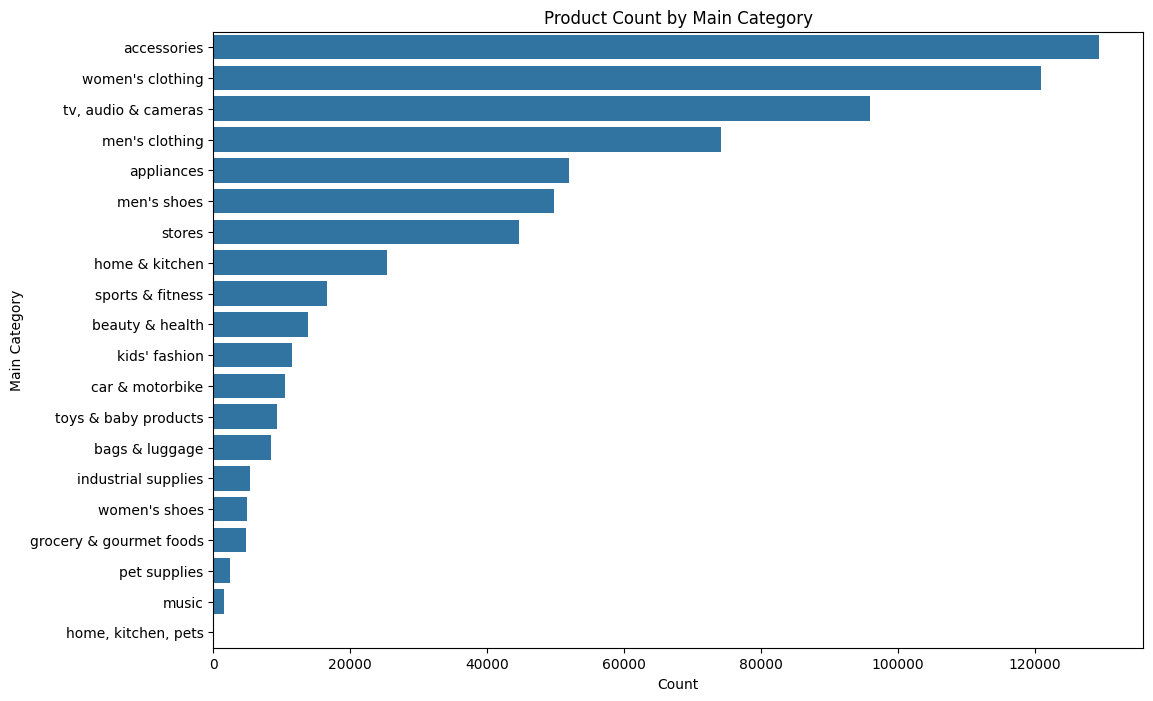

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Count plot of main categories
plt.figure(figsize=(12, 8))
sns.countplot(y='main_category', data=merged_df, order=merged_df['main_category'].value_counts().index)
plt.title('Product Count by Main Category')
plt.xlabel('Count')
plt.ylabel('Main Category')
plt.show()

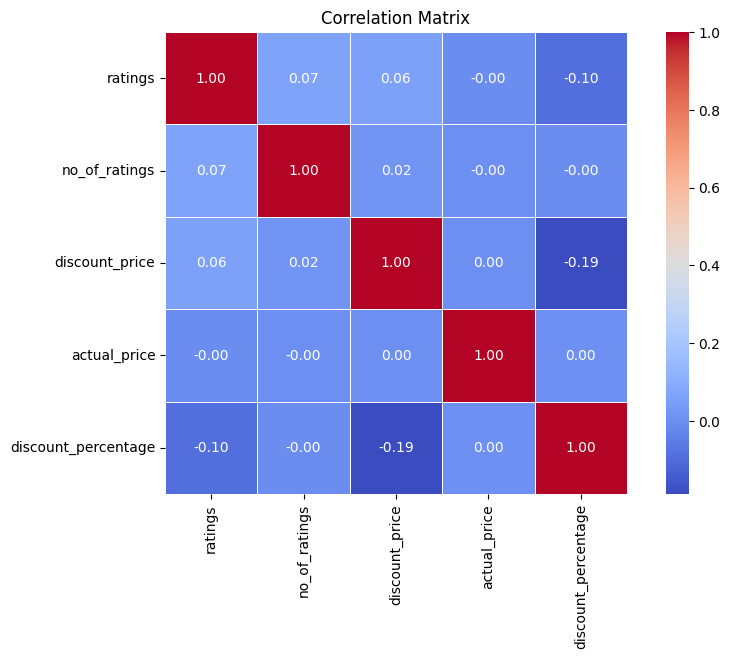

In [ ]:

# Calculate correlation matrix
correlation_matrix = merged_df[['ratings', 'no_of_ratings', 'discount_price', 'actual_price', 'discount_percentage']].corr()

# Heatmap for correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=.5)
plt.title('Correlation Matrix')
plt.show()


In [ ]:
# Top products by ratings
top_rated_products = merged_df.loc[merged_df.groupby('main_category')['ratings'].idxmax()][['name', 'main_category', 'ratings']]
print("\nTop Rated Products:")
print(top_rated_products)


Top Rated Products:
                                                    name  \
35327  earthsave Cotton Premium Sling Bag|Canvas Slin...   
34572  Hitachi Split Ac - 1.5 Ton Kiyora 5200Fx I Fre...   
35271  Lavie Sport Chief 34 litres Business Laptop Ba...   
35795  DarkPyro Ice Roller For Face, Neck and Body | ...   
34791  Cheston High Pressure Washer with Copper Windi...   
34833  Orion Turtle Chips Party snack - Hot Lime 130g...   
34842  IGNITO oval shape adhesive mirror sticker for ...   
43779  (Renewed) Usha Mist Air ICY 400MM Wall Fan wit...   
40697  SEIBEN Handheld Wireless Car Vacuum Cleaner, C...   
35226  superbottoms Top & Shorts Set | Evrydaywear| C...   
40701  Levi's Men's 066 Active Brief with Smartskin T...   
36474                    crocs Unisex-Adult Classic Clog   
43647   Planet Waves 1NFX6 Guitar Pick, Pack of 10, Grey   
34846  Elysian Bird House Wild Bird House for Garden ...   
34819  FitBlaze Tummy Twister | Waist Trimmer | Ab Tw...   
34868  DIY Crafts W

In [ ]:
# Average ratings by category
average_ratings = merged_df.groupby('main_category')['ratings'].mean().sort_values(ascending=False)
print("\nAverage Ratings by Category:")
print(average_ratings)



Average Ratings by Category:
main_category
grocery & gourmet foods    4.059496
toys & baby products       4.012263
pet supplies               4.009334
beauty & health            3.985691
home & kitchen             3.974760
music                      3.928877
bags & luggage             3.898101
accessories                3.893068
stores                     3.863711
appliances                 3.843524
kids' fashion              3.834223
industrial supplies        3.820833
tv, audio & cameras        3.817645
sports & fitness           3.795765
women's clothing           3.754719
men's clothing             3.751430
car & motorbike            3.719957
women's shoes              3.654908
men's shoes                3.599170
home, kitchen, pets        3.408333
Name: ratings, dtype: float64


In [ ]:
# Most discounted products
most_discounted_products = merged_df.nlargest(10, 'discount_percentage')[['name', 'main_category', 'discount_percentage']]
print("\nMost Discounted Products:")
print(most_discounted_products)



Most Discounted Products:
                                                     name     main_category  \
3635    Marutivilla Insect Killer, Mosquito Killer Lig...    home & kitchen   
96705   Marutivilla Insect Killer, Mosquito Killer Lig...    home & kitchen   
200656  Clovia Women's Activewear Ankle Length Printed...  sports & fitness   
287870  Clovia Women's Activewear Ankle Length Printed...  sports & fitness   
194664                              Amazon Pay eGift Card       accessories   
281045                              Amazon Pay eGift Card    bags & luggage   
281522                              Amazon Pay eGift Card       accessories   
284363                              Amazon Pay eGift Card    bags & luggage   
79725   IONIX ro pipe 10 Meters length, Ro tubing 1/4 ...        appliances   
79726   IONIX ro pipe 10 Meters length, Ro tubing 1/4 ...        appliances   

        discount_percentage  
3635              99.999994  
96705             99.999994  
200656       

In [ ]:
# Average discount percentage by category
average_discount_percentage = merged_df.groupby('main_category')['discount_percentage'].mean().sort_values(ascending=False)
print("\nAverage Discount Percentage by Category:")
print(average_discount_percentage)


Average Discount Percentage by Category:
main_category
women's clothing           59.971139
accessories                57.555868
stores                     52.325508
bags & luggage             51.439542
kids' fashion              49.789917
tv, audio & cameras        49.539656
men's clothing             48.158456
sports & fitness           48.107794
home & kitchen             47.745918
car & motorbike            46.354119
women's shoes              45.509907
men's shoes                44.440859
industrial supplies        41.458108
appliances                 39.698672
toys & baby products       39.357470
music                      38.880003
pet supplies               35.552109
beauty & health            32.907345
grocery & gourmet foods    23.147062
home, kitchen, pets        14.863161
Name: discount_percentage, dtype: float64


In [ ]:
# Set display option for floats to prevent scientific notation
pd.set_option('display.float_format', '{:.2f}'.format)

# Price range by category
price_range = merged_df.groupby('main_category')['actual_price'].agg(['min', 'max'])
print("\nPrice Range by Category:")
print(price_range)



Price Range by Category:
                            min           max
main_category                                
accessories               30.00     700300.00
appliances                60.00     316990.00
bags & luggage            80.00     190000.00
beauty & health           10.00      87326.00
car & motorbike           63.00     104757.00
grocery & gourmet foods   10.00      38000.00
home & kitchen            30.00 9899999999.00
home, kitchen, pets     1499.00       9290.00
industrial supplies       59.00     160952.00
kids' fashion             99.00     123719.00
men's clothing           100.00      22956.00
men's shoes               39.00      39900.00
music                     60.00     122440.00
pet supplies              40.00      25890.00
sports & fitness          95.00   61082990.00
stores                    33.00     123719.00
toys & baby products      15.00      55200.00
tv, audio & cameras       30.00    1594900.00
women's clothing          99.00      21999.00
women's 

In [ ]:
# Count of products per category
product_count = merged_df['main_category'].value_counts()
print("\nCount of Products per Category:")
print(product_count)


Count of Products per Category:
main_category
accessories                129380
women's clothing           120906
tv, audio & cameras         95914
men's clothing              74196
appliances                  51946
men's shoes                 49790
stores                      44602
home & kitchen              25320
sports & fitness            16642
beauty & health             13830
kids' fashion               11518
car & motorbike             10526
toys & baby products         9296
bags & luggage               8478
industrial supplies          5344
women's shoes                4914
grocery & gourmet foods      4714
pet supplies                 2502
music                        1518
home, kitchen, pets            24
Name: count, dtype: int64
